In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_image(path="cat.png"):
    image = cv2.imread(path)
    if image is not None:
        return image

    # Fallback image so the notebook still runs if the file is missing.
    gray = np.tile(np.linspace(0, 255, 256, dtype=np.uint8), (256, 1))
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)


In [3]:

def show_pair(left, right, left_title, right_title, left_gray=False, right_gray=False):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(left, cmap="gray" if left_gray else None)
    plt.title(left_title)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(right, cmap="gray" if right_gray else None)
    plt.title(right_title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



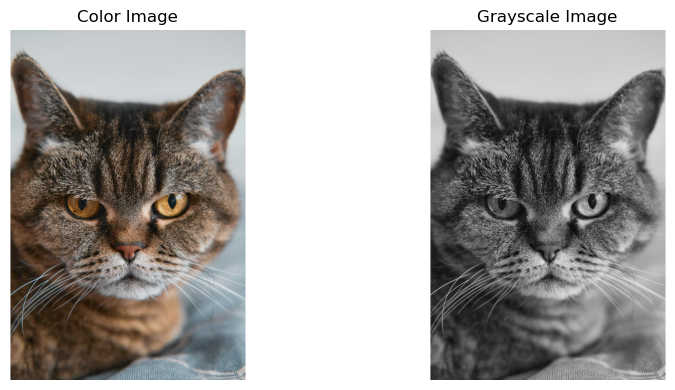

In [4]:
# Read and display image
I0 = load_image("cat.png")
I = cv2.cvtColor(I0, cv2.COLOR_BGR2GRAY)
I0_rgb = cv2.cvtColor(I0, cv2.COLOR_BGR2RGB)

show_pair(I0_rgb, I, "Color Image", "Grayscale Image", right_gray=True)


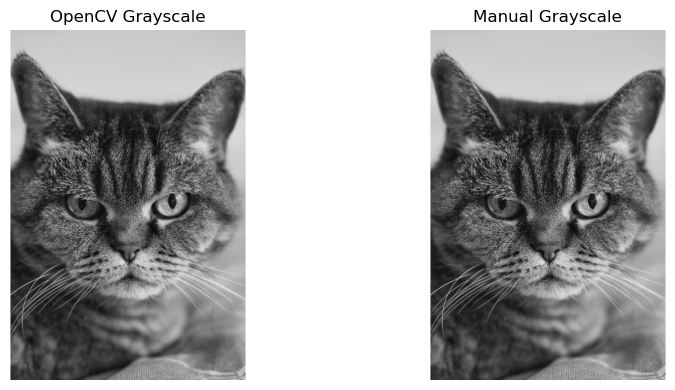

In [12]:
# Manually convert to grayscale using the luminosity method
def rgb_to_grayscale(rgb_image):
    # Extract the R, G, B channels
    R = rgb_image[:, :, 0]
    G = rgb_image[:, :, 1]
    B = rgb_image[:, :, 2]

    # Apply the luminosity formula
    grayscale = 0.299 * R + 0.587 * G + 0.114 * B

    # Convert to uint8 type
    return grayscale.astype(np.uint8)

I_manual_gray = rgb_to_grayscale(I0_rgb)
show_pair(I, I_manual_gray, "OpenCV Grayscale", "Manual Grayscale", left_gray=True, right_gray=True)

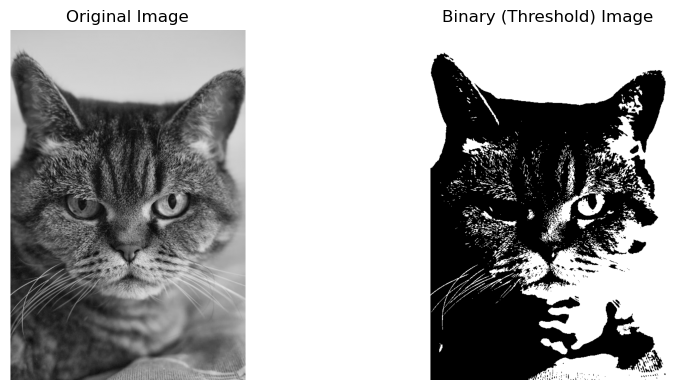

In [5]:
# Image thresholding
Ib = cv2.threshold(I, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
show_pair(I, Ib, "Original Image", "Binary (Threshold) Image", left_gray=True, right_gray=True)

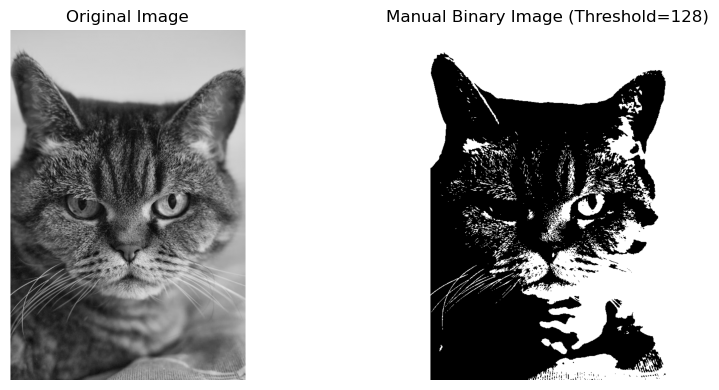

In [13]:
# Manually Implement Image Thresholding
def manual_threshold(image, threshold):
    binary_image = np.zeros_like(image, dtype=np.uint8)
    binary_image[image > threshold] = 255
    return binary_image
threshold_value = 128  # Example threshold value
Ib_manual = manual_threshold(I, threshold_value)
show_pair(I, Ib_manual, "Original Image", f"Manual Binary Image (Threshold={threshold_value})", left_gray=True, right_gray=True)

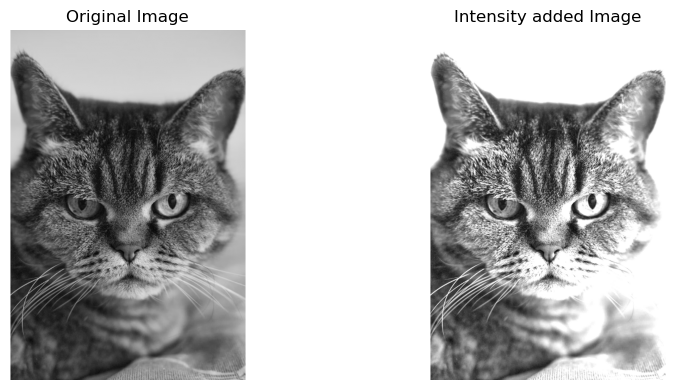

In [6]:
# Adding intensity levels
Id1 = cv2.add(I, 100)
show_pair(I, Id1, "Original Image", "Intensity added Image", left_gray=True, right_gray=True)

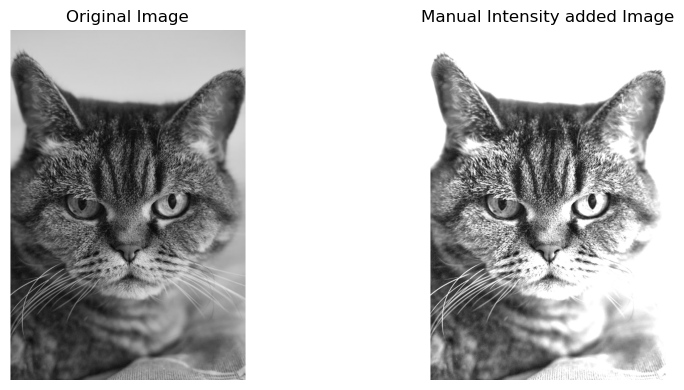

In [14]:
# Manually Adding intensity levels
def add_intensity(image, value):
    # Convert to int16 to prevent overflow
    temp_image = image.astype(np.int16) + value
    # Clip values to the range [0, 255] and convert back to uint8
    return np.clip(temp_image, 0, 255).astype(np.uint8)
Id1_manual = add_intensity(I, 100)
show_pair(I, Id1_manual, "Original Image", "Manual Intensity added Image", left_gray=True, right_gray=True)

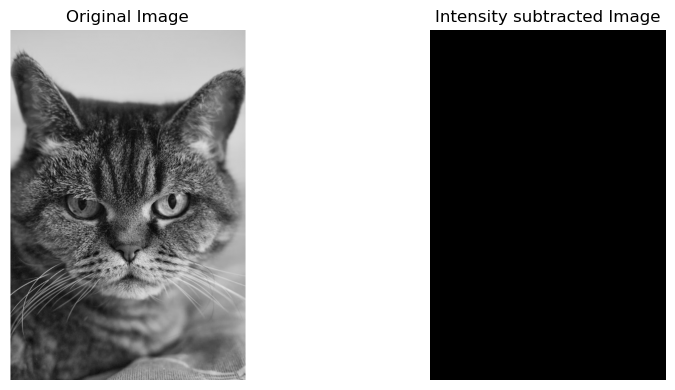

In [7]:
# Subtracting intensity levels
Id2 = cv2.subtract(I, 255)
show_pair(I, Id2, "Original Image", "Intensity subtracted Image", left_gray=True, right_gray=True)

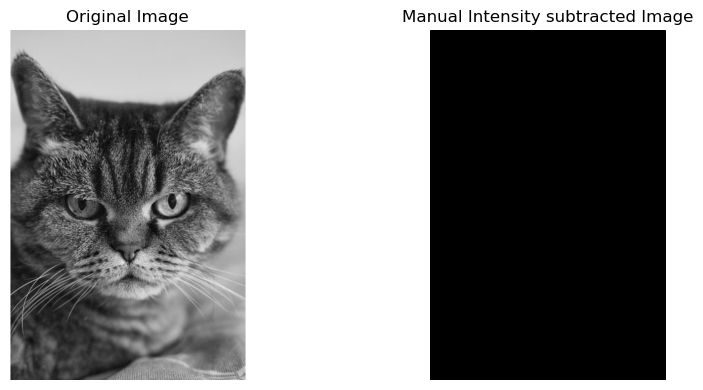

In [15]:
# Manually Subtracting intensity levels
def subtract_intensity(image, value):
    # Convert to int16 to prevent underflow
    temp_image = image.astype(np.int16) - value
    # Clip values to the range [0, 255] and convert back to uint8
    return np.clip(temp_image, 0, 255).astype(np.uint8)
Id2_manual = subtract_intensity(I, 255)
show_pair(I, Id2_manual, "Original Image", "Manual Intensity subtracted Image", left_gray=True, right_gray=True)

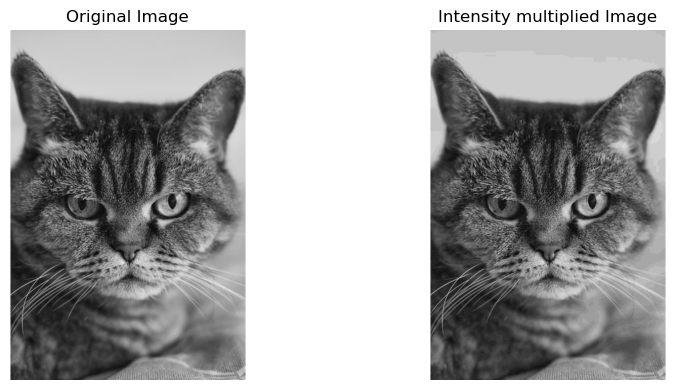

In [8]:
# Multiply intensity levels
Id3 = cv2.convertScaleAbs(I, alpha=0.1, beta=0)
show_pair(I, Id3, "Original Image", "Intensity multiplied Image", left_gray=True, right_gray=True)

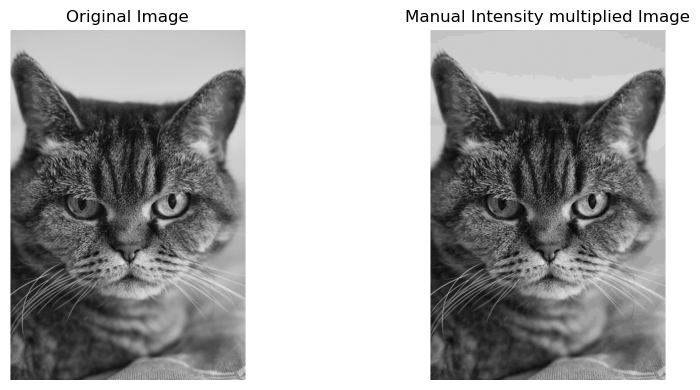

In [16]:
# Manually Implementing Multiply intensity levels
def multiply_intensity(image, factor):
    # Convert to float32 for multiplication
    temp_image = image.astype(np.float32) * factor
    # Clip values to the range [0, 255] and convert back to uint8
    return np.clip(temp_image, 0, 255).astype(np.uint8)
Id3_manual = multiply_intensity(I, 0.1)
show_pair(I, Id3_manual, "Original Image", "Manual Intensity multiplied Image", left_gray=True, right_gray=True)

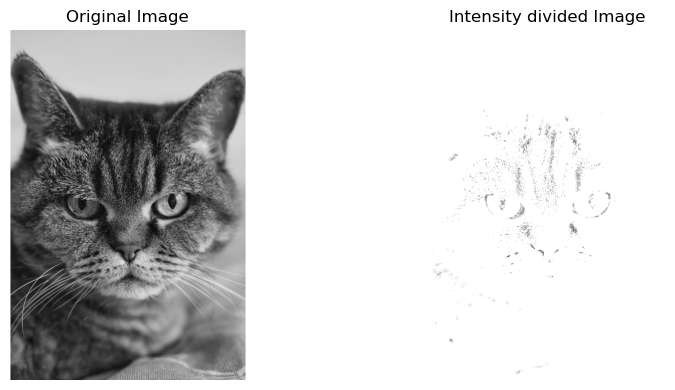

In [9]:
# Divide intensity levels
Id4 = cv2.convertScaleAbs(I, alpha=10.0, beta=0)
show_pair(I, Id4, "Original Image", "Intensity divided Image", left_gray=True, right_gray=True)

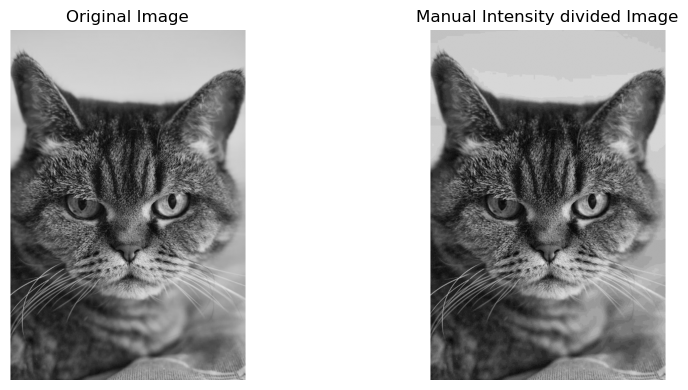

In [17]:
# Manually Implementing Divide intensity levels
def divide_intensity(image, factor):
    # Convert to float32 for division
    temp_image = image.astype(np.float32) / factor
    # Clip values to the range [0, 255] and convert back to uint8
    return np.clip(temp_image, 0, 255).astype(np.uint8)
Id4_manual = divide_intensity(I, 10.0)
show_pair(I, Id4_manual, "Original Image", "Manual Intensity divided Image", left_gray=True, right_gray=True)

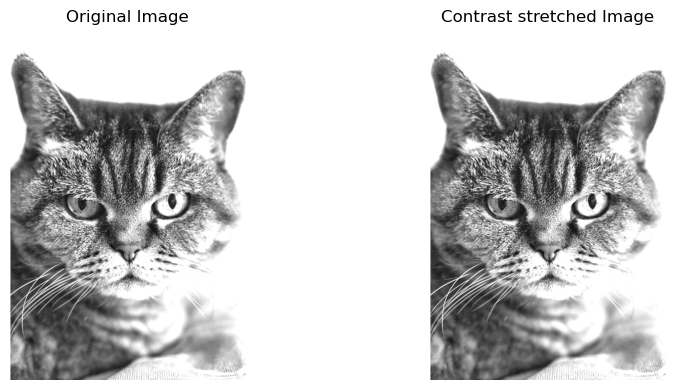

In [10]:
# Contrast stretching
I_contrast = cv2.add(I, 100)
J = cv2.normalize(I_contrast, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
show_pair(I_contrast, J, "Original Image", "Contrast stretched Image", left_gray=True, right_gray=True)

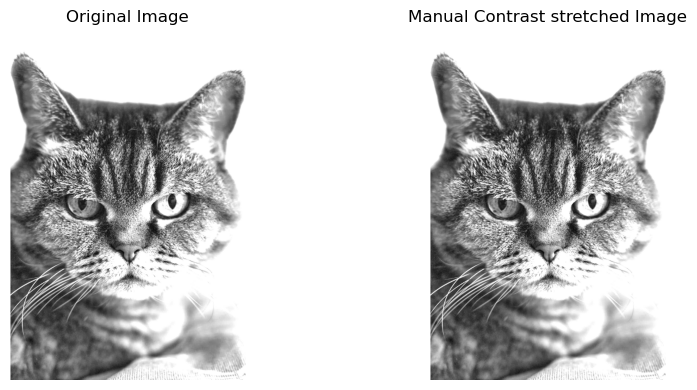

In [21]:
# Manually Implementing Contrast stretching
def contrast_stretching(image, low_in, high_in, low_out, high_out):
    # Scale the input image to the range [0, 1]
    scaled = (image - low_in) / (high_in - low_in)
    # Scale to the output range and clip
    stretched = scaled * (high_out - low_out) + low_out
    return np.clip(stretched, 0, 255).astype(np.uint8)
I_contrast_manual = add_intensity(I, 100)
J_manual = contrast_stretching(I_contrast_manual, low_in=I_contrast_manual.min(), high_in=I_contrast_manual.max(), low_out=0, high_out=255)
show_pair(I_contrast_manual, J_manual, "Original Image", "Manual Contrast stretched Image", left_gray=True, right_gray=True)